# Pb-212: does the Bayesian MAP estimator add value over an improved classical fit?

A Monte Carlo comparison of three estimators for recovering (initial activity A0,
half-life, background B) from counting data, using <sup>212</sup>Pb as a realistic
short-lived test case:

1. **Log-linear** (`bayesdecay.model.loglinear_fit`) -- unweighted OLS regression of
   log(rate) vs. time. Cannot estimate background at all: `log(A0*exp(-lam*t) + B)`
   isn't linear in `t` for `B != 0`, so this is structurally blind to it (see the
   function's docstring) -- kept here mainly as a reference for how much a real
   background costs a method that ignores it entirely.
2. **Nonlinear least-squares** (`bayesdecay.model.nonlinear_fit`) -- a classical fit
   that DOES include background, by fitting `A0*exp(-lambda*t) + B` directly
   (weighted by Poisson standard error) instead of log-linearizing it away. This is
   the fair classical competitor: it fixes log-linear's one obvious structural gap
   without going Bayesian.
3. **Bayesian MAP** (`bayesdecay.fit`) -- the full Poisson likelihood plus weakly-
   informative priors.

**Reference half-life** (ground truth for every simulation below):

> T<sub>1/2</sub> = 10.630(7) h = 38268(25) s
>
> DDEP evaluation, B. E. Zimmerman (NIST), completed May 2025 -- the most recent
> published DDEP half-life for <sup>212</sup>Pb (weighted mean of 9 independent
> measurements; supersedes the 2011 DDEP value of 10.64(1) h and the 2020 ENSDF
> value of 10.622(7) h). Source: http://www.lnhb.fr/nuclides/Pb-212_com.pdf

**Scenario**: a single counter, initial activity A0 = 50000 cps ("reasonable in a
good counting system"). The measurement time is fixed at 10 half-lives throughout --
long enough that the source's own signal has decayed to a small fraction of A0
(testing whether each method handles a background that actually matters relative to
the late-time signal, not one that's negligible by construction) -- and the TRUE
background is swept from 10<sup>-2</sup> down to 10<sup>-6</sup> of A0.
`Part 1` uses the non-paralyzable dead-time model, `Part 2` repeats the same sweep
with the paralyzable model, to check the conclusion isn't specific to one.

Each Monte Carlo point is an independent simulated dataset, fit with all three
estimators; repeating many times at each setting measures each estimator's actual
bias and 95% CI coverage -- not just a single lucky (or unlucky) draw.


In [1]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import bayesdecay as bd

plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})
COLOR_LL = "tab:orange"
COLOR_NL = "tab:green"
COLOR_MAP = "tab:blue"
Z95 = 1.959963984540054  # norm.ppf(0.975)


## Scenario constants

In [2]:
# 212Pb half-life, DDEP evaluation (NIST/B. Zimmerman, May 2025): 10.630(7) h
T12_TRUE = 10.630 * 3600.0        # s
U_T12_TRUE = 0.007 * 3600.0       # s

A0_TRUE = 50_000.0                # cps -- "reasonable in a good counting system"
TAU_D = 1e-6                      # s (1 microsecond dead time)
T_MES_LONG = 10.0 * T12_TRUE       # fixed measurement time for every sweep below
B_RATIOS = [1e-2, 1e-3, 1e-4, 1e-5, 1e-6]

end_signal_rate = A0_TRUE * np.exp(-np.log(2) * 10.0)
print(f"T1/2 = {T12_TRUE:.1f} +/- {U_T12_TRUE:.1f} s  ({T12_TRUE / 3600:.4f} h)")
print(f"A0   = {A0_TRUE:.0f} cps,  dead time = {TAU_D * 1e6:.1f} us")
print(f"t_mes = {T_MES_LONG:.0f} s (10 x T1/2); true signal rate at t_mes: {end_signal_rate:.2f} cps")
for r in B_RATIOS:
    print(f"  B/A0={r:.0e}  ->  B={r * A0_TRUE:.3g} cps")


T1/2 = 38268.0 +/- 25.2 s  (10.6300 h)
A0   = 50000 cps,  dead time = 1.0 us
t_mes = 382680 s (10 x T1/2); true signal rate at t_mes: 48.83 cps
  B/A0=1e-02  ->  B=500 cps
  B/A0=1e-03  ->  B=50 cps
  B/A0=1e-04  ->  B=5 cps
  B/A0=1e-05  ->  B=0.5 cps
  B/A0=1e-06  ->  B=0.05 cps


## Monte Carlo machinery

`run_mc` simulates `n_rep` independent datasets at one (half-life, background,
measurement time, dead-time model) setting and fits each with all three estimators.
The `FitConfig` below trims the library's default grid/importance-sampling
resolution (`n_vis`, `n_is_samples`) to keep a multi-point Monte Carlo sweep
tractable -- still resolves the posterior correctly, just with a coarser
smoothed-marginal display than the library's default.

The background prior scale (for the Bayesian MAP estimator) is set to a generous
`0.1 * A0_TRUE` (5000 cps) -- wide enough to stay uninformative across the *entire*
background sweep (true B ranges from 0.05 to 500 cps), so the comparison below
reflects the estimators' statistical handling of background, not a lucky/unlucky
prior choice.


In [3]:
def run_mc(half_life_true, background_true, t_max, n_rep, fit_config, dead_time_model, seed0=0,
           A0_true=A0_TRUE, tau_d=TAU_D):
    '''Simulate n_rep independent datasets at the given setting and fit each with all
    three estimators (log-linear, nonlinear least-squares, Bayesian MAP). One row per
    repetition.'''
    lam = np.log(2) / half_life_true
    rows = []
    for i in range(n_rep):
        rng = np.random.default_rng(seed0 + i)
        n_bins, _ = bd.auto_bin_count(
            A0_true, lam, background_true, t_max, tau_d,
            dead_time_model=dead_time_model, rng=rng,
        )
        bin_edges, counts = bd.simulate_binned(
            A0_true, lam, background_true, t_max, tau_d, n_bins,
            dead_time_model=dead_time_model, rng=rng,
        )
        bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
        bin_width = np.diff(bin_edges)

        A0_ll, t12_ll, _, sA0_ll, st12_ll = bd.loglinear_fit(
            bin_centers, counts, bin_width, t_max, tau_d=tau_d, dead_time_model=dead_time_model,
        )
        A0_nl, t12_nl, B_nl, sA0_nl, st12_nl, sB_nl = bd.nonlinear_fit(
            bin_centers, counts, bin_width, t_max, tau_d=tau_d, dead_time_model=dead_time_model,
        )
        result = bd.fit(bin_edges, counts, tau_d, config=fit_config, show_progress=False)

        rows.append(dict(
            rep=i, n_bins=n_bins, total_counts=int(counts.sum()),
            half_life_true=half_life_true, background_true=background_true, t_max=t_max,
            A0_ll=A0_ll, half_life_ll=t12_ll, sA0_ll=sA0_ll, st12_ll=st12_ll,
            A0_nl=A0_nl, half_life_nl=t12_nl, background_nl=B_nl,
            sA0_nl=sA0_nl, st12_nl=st12_nl, sB_nl=sB_nl,
            A0_map=result.A0, half_life_map=result.half_life, background_map=result.background,
            sA0_map=result.u_A0, st12_map=result.u_half_life, sB_map=result.u_background,
            A0_map_lo=result.A0_ci95[0], A0_map_hi=result.A0_ci95[1],
            t12_map_lo=result.half_life_ci95[0], t12_map_hi=result.half_life_ci95[1],
            B_map_lo=result.background_ci95[0], B_map_hi=result.background_ci95[1],
            converged=result.converged,
        ))
    return pd.DataFrame(rows)


def _stats(est, true, sigma=None, lo=None, hi=None):
    err = (np.asarray(est, dtype=float) - true) / true
    out = {
        "bias_pct": 100 * np.mean(err),
        "bias_sem_pct": 100 * np.std(err, ddof=1) / np.sqrt(len(err)),
        "rmse_pct": 100 * np.sqrt(np.mean(err**2)),
    }
    if sigma is not None:
        out["rel_unc_pct"] = 100 * np.mean(np.asarray(sigma, dtype=float) / true)
    if lo is not None:
        cov = (np.asarray(lo, dtype=float) <= true) & (true <= np.asarray(hi, dtype=float))
        out["coverage"] = np.mean(cov)
    return out


def summarize(df, true_A0, true_t12, true_B=None):
    '''Collapse one run_mc() DataFrame (repeated draws at ONE setting) into bias /
    RMSE / mean relative reported uncertainty / empirical 95% coverage, per
    parameter and estimator. Background is nl/map-only: loglinear_fit never
    estimates it (see its docstring).'''
    A0_ll_lo = df["A0_ll"] - Z95 * df["sA0_ll"]
    A0_ll_hi = df["A0_ll"] + Z95 * df["sA0_ll"]
    t12_ll_lo = df["half_life_ll"] - Z95 * df["st12_ll"]
    t12_ll_hi = df["half_life_ll"] + Z95 * df["st12_ll"]
    A0_nl_lo = df["A0_nl"] - Z95 * df["sA0_nl"]
    A0_nl_hi = df["A0_nl"] + Z95 * df["sA0_nl"]
    t12_nl_lo = df["half_life_nl"] - Z95 * df["st12_nl"]
    t12_nl_hi = df["half_life_nl"] + Z95 * df["st12_nl"]

    out = {
        "A0_ll": _stats(df["A0_ll"], true_A0, df["sA0_ll"], A0_ll_lo, A0_ll_hi),
        "A0_nl": _stats(df["A0_nl"], true_A0, df["sA0_nl"], A0_nl_lo, A0_nl_hi),
        "A0_map": _stats(df["A0_map"], true_A0, df["sA0_map"], df["A0_map_lo"], df["A0_map_hi"]),
        "t12_ll": _stats(df["half_life_ll"], true_t12, df["st12_ll"], t12_ll_lo, t12_ll_hi),
        "t12_nl": _stats(df["half_life_nl"], true_t12, df["st12_nl"], t12_nl_lo, t12_nl_hi),
        "t12_map": _stats(df["half_life_map"], true_t12, df["st12_map"], df["t12_map_lo"], df["t12_map_hi"]),
    }
    if true_B is not None and true_B > 0:
        B_nl_lo = df["background_nl"] - Z95 * df["sB_nl"]
        B_nl_hi = df["background_nl"] + Z95 * df["sB_nl"]
        out["B_nl"] = _stats(df["background_nl"], true_B, df["sB_nl"], B_nl_lo, B_nl_hi)
        out["B_map"] = _stats(df["background_map"], true_B, df["sB_map"], df["B_map_lo"], df["B_map_hi"])
    return out


def build_summary_table(raw_dict, sweep_name, sweep_values, true_A0, true_t12, true_B=None):
    records = []
    for v in sweep_values:
        df = raw_dict[v]
        tb = true_B(v) if callable(true_B) else true_B
        s = summarize(df, true_A0, true_t12, tb)
        for key, d in s.items():
            param, est = key.split("_")
            rec = {sweep_name: v, "param": param, "estimator": est}
            rec.update(d)
            records.append(rec)
    return pd.DataFrame(records)


ESTIMATORS = [
    ("ll", COLOR_LL, "o", "Log-linear"),
    ("nl", COLOR_NL, "^", "Nonlinear LSQ"),
    ("map", COLOR_MAP, "s", "Bayesian MAP"),
]


def plot_metric(summary, sweep_col, params, metric, title, xlabel, ylabel,
                 logx=True, ref_line=None):
    fig, axes = plt.subplots(1, len(params), figsize=(5.8 * len(params), 4.2), sharex=True)
    axes = np.atleast_1d(axes)
    for ax, (param, label) in zip(axes, params):
        for est, color, marker, est_label in ESTIMATORS:
            sub = summary[(summary["param"] == param) & (summary["estimator"] == est)].sort_values(sweep_col)
            if sub.empty:
                continue
            yerr = sub["bias_sem_pct"] if metric == "bias_pct" and "bias_sem_pct" in sub else None
            ax.errorbar(
                sub[sweep_col], sub[metric], yerr=yerr,
                marker=marker, color=color, label=est_label, capsize=3, lw=1.5, markersize=6,
            )
        if ref_line is not None:
            ax.axhline(ref_line, color="0.4", lw=1, ls="--")
        ax.set_title(label)
        ax.set_xlabel(xlabel)
        if logx:
            ax.set_xscale("log")
    axes[0].set_ylabel(ylabel)
    axes[0].legend(frameon=False)
    fig.suptitle(title)
    fig.tight_layout()
    return fig


def print_bias_summary(summary, label):
    print(f"{label} (bias, log-linear / nonlinear-LSQ / MAP):")
    for param, pretty in [("A0", "A0"), ("t12", "half-life"), ("B", "background")]:
        sub = summary[summary["param"] == param]
        if sub.empty:
            continue
        print(f"  {pretty}:")
        for v in sorted(sub[summary.columns[0]].unique(), reverse=True):
            row = sub[sub[summary.columns[0]] == v]
            parts = []
            for est, _, _, est_label in ESTIMATORS:
                r = row[row["estimator"] == est]
                if not r.empty:
                    parts.append(f"{est_label}={r['bias_pct'].iloc[0]:+6.2f}%")
            print(f"    {summary.columns[0]}={v:.3g}: " + "  ".join(parts))


## Part 1 -- non-paralyzable dead-time model

In [4]:
N_REP = 10

PRIORS_WIDE_B = bd.Priors(b_prior_scale=0.1 * A0_TRUE, prior_widen_k=5.0, prior_df=4.0)
FIT_CONFIG_NONPARA = bd.FitConfig(
    dead_time_model="nonparalyzable", n_vis=41, n_is_samples=5000, n_checkpoints=3,
    priors=PRIORS_WIDE_B,
)

part1_raw = {}
t0_all = time.time()
for ratio in B_RATIOS:
    B_true = ratio * A0_TRUE
    t0 = time.time()
    df = run_mc(
        T12_TRUE, B_true, T_MES_LONG, N_REP, FIT_CONFIG_NONPARA, "nonparalyzable",
        seed0=1000 + int(-np.log10(ratio) * 100),
    )
    dt = time.time() - t0
    part1_raw[ratio] = df
    print(f"B/A0={ratio:.0e}  B={B_true:>7.3g} cps  converged={df['converged'].mean() * 100:.0f}%  ({dt:.0f}s)")
print(f"Part 1 total: {time.time() - t0_all:.0f}s")


B/A0=1e-02  B=    500 cps  converged=100%  (441s)
B/A0=1e-03  B=     50 cps  converged=100%  (424s)
B/A0=1e-04  B=      5 cps  converged=100%  (355s)
B/A0=1e-05  B=    0.5 cps  converged=100%  (290s)
B/A0=1e-06  B=   0.05 cps  converged=100%  (189s)
Part 1 total: 1700s


In [5]:
part1_summary = build_summary_table(
    part1_raw, "b_ratio", B_RATIOS, A0_TRUE, T12_TRUE, true_B=lambda r: r * A0_TRUE,
)
part1_summary.round(4)


,b_ratio,param,estimator,bias_pct,bias_sem_pct,rmse_pct,rel_unc_pct,coverage
0,0.0100,A0,ll,-38.3006,0.0011,38.3006,1.6507,0.0
1,0.0100,A0,nl,0.0007,0.0008,0.0026,0.0029,1.0
2,0.0100,A0,map,0.0764,0.0842,0.2640,0.1643,0.8
3,0.0100,t12,ll,46.2116,0.0015,46.2116,1.4292,0.0
4,0.0100,t12,nl,-0.0004,0.0008,0.0025,0.0028,0.9
5,0.0100,t12,map,-0.0185,0.0768,0.2312,0.1195,1.0
6,0.0100,B,nl,0.0004,0.0043,0.0129,0.0158,1.0
7,0.0100,B,map,0.2073,0.3717,1.1342,0.6745,0.9
8,0.0010,A0,ll,-11.9965,0.0015,11.9965,0.6880,0.0
9,0.0010,A0,nl,0.0013,0.0011,0.0036,0.0028,0.9


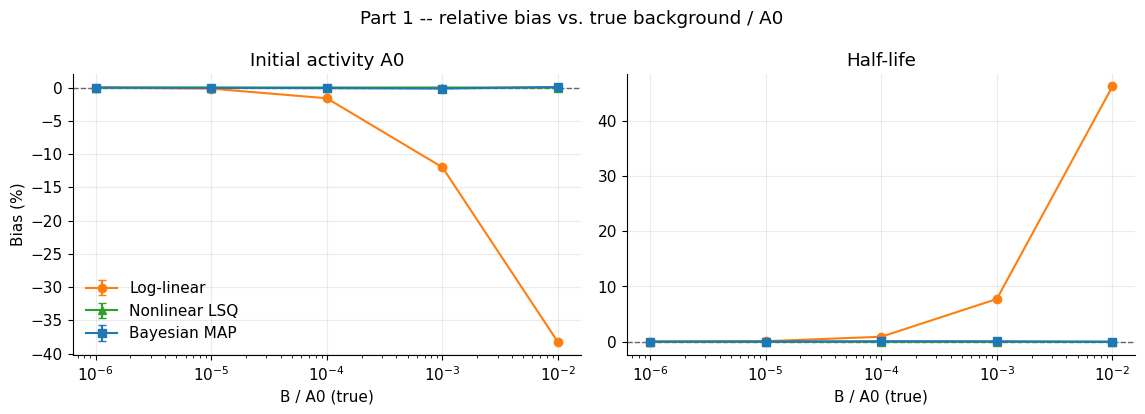

In [6]:
fig = plot_metric(
    part1_summary, "b_ratio",
    [("A0", "Initial activity A0"), ("t12", "Half-life")],
    "bias_pct", "Part 1 -- relative bias vs. true background / A0", "B / A0 (true)", "Bias (%)",
    ref_line=0.0,
)
plt.show()


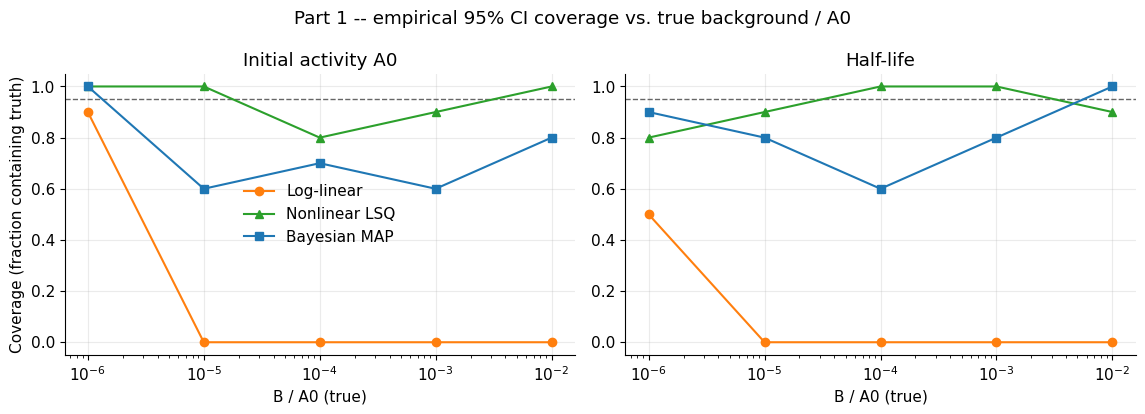

In [7]:
fig = plot_metric(
    part1_summary, "b_ratio",
    [("A0", "Initial activity A0"), ("t12", "Half-life")],
    "coverage", "Part 1 -- empirical 95% CI coverage vs. true background / A0", "B / A0 (true)",
    "Coverage (fraction containing truth)", ref_line=0.95,
)
for ax in fig.axes:
    ax.set_ylim(-0.05, 1.05)
plt.show()


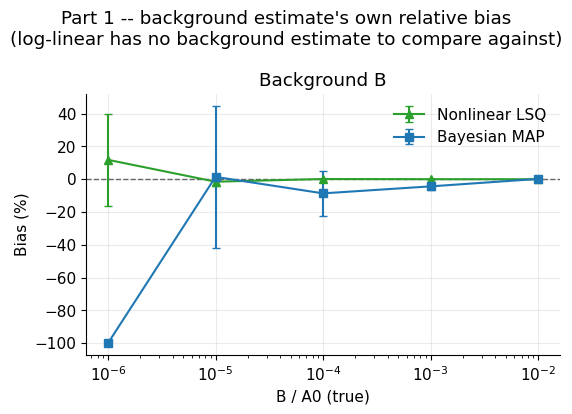

In [8]:
fig = plot_metric(
    part1_summary, "b_ratio", [("B", "Background B")],
    "bias_pct", "Part 1 -- background estimate's own relative bias\n(log-linear has no background estimate to compare against)",
    "B / A0 (true)", "Bias (%)", ref_line=0.0,
)
plt.show()


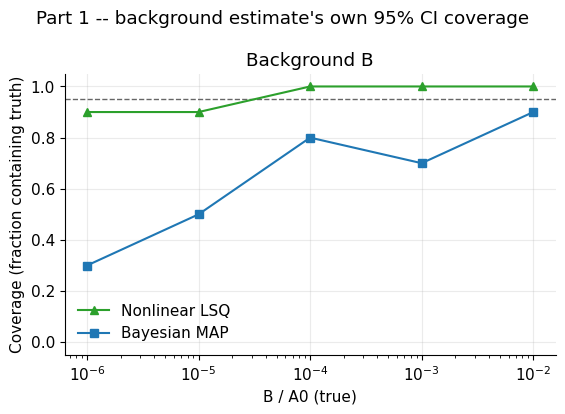

In [9]:
fig = plot_metric(
    part1_summary, "b_ratio", [("B", "Background B")],
    "coverage", "Part 1 -- background estimate's own 95% CI coverage", "B / A0 (true)",
    "Coverage (fraction containing truth)", ref_line=0.95,
)
fig.axes[0].set_ylim(-0.05, 1.05)
plt.show()


In [10]:
print_bias_summary(part1_summary, "Part 1")


Part 1 (bias, log-linear / nonlinear-LSQ / MAP):
  A0:
    b_ratio=0.01: Log-linear=-38.30%  Nonlinear LSQ= +0.00%  Bayesian MAP= +0.08%
    b_ratio=0.001: Log-linear=-12.00%  Nonlinear LSQ= +0.00%  Bayesian MAP= -0.16%
    b_ratio=0.0001: Log-linear= -1.61%  Nonlinear LSQ= +0.00%  Bayesian MAP= -0.09%
    b_ratio=1e-05: Log-linear= -0.16%  Nonlinear LSQ= +0.00%  Bayesian MAP= -0.05%
    b_ratio=1e-06: Log-linear= -0.02%  Nonlinear LSQ= -0.00%  Bayesian MAP= -0.02%
  half-life:
    b_ratio=0.01: Log-linear=+46.21%  Nonlinear LSQ= -0.00%  Bayesian MAP= -0.02%
    b_ratio=0.001: Log-linear= +7.73%  Nonlinear LSQ= -0.00%  Bayesian MAP= +0.06%
    b_ratio=0.0001: Log-linear= +0.89%  Nonlinear LSQ= -0.00%  Bayesian MAP= +0.08%
    b_ratio=1e-05: Log-linear= +0.09%  Nonlinear LSQ= +0.00%  Bayesian MAP= +0.02%
    b_ratio=1e-06: Log-linear= +0.01%  Nonlinear LSQ= +0.00%  Bayesian MAP= +0.01%
  background:
    b_ratio=0.01: Nonlinear LSQ= +0.00%  Bayesian MAP= +0.21%
    b_ratio=0.001: Nonline

**Reading Part 1**: log-linear's bias grows sharply once B/A0 isn't negligible,
exactly as expected from a method that never estimates it (see
`loglinear_fit`'s docstring). The real question this notebook asks is in the
"Nonlinear LSQ" vs. "Bayesian MAP" comparison: once the classical method is no
longer structurally blind to background, does the full Bayesian treatment still
add anything? Compare their bias, and their coverage, across the sweep above --
and see the Conclusions section for the answer at a glance.


## Part 2 -- paralyzable dead-time model

Repeats Part 1's sweep with `dead_time_model = "paralyzable"` instead (every true
event, recorded or not, restarts the dead period -- qualitatively different from
non-paralyzable, see `bayesdecay.deadtime`), same A0 and dead time (comfortably
below the paralyzable model's turnover rate here, so this stays in its "normal"
monotonic regime), to check the Part 1 conclusion isn't an artifact of one
particular dead-time model.


In [11]:
FIT_CONFIG_PARA = bd.FitConfig(
    dead_time_model="paralyzable", n_vis=41, n_is_samples=5000, n_checkpoints=3,
    priors=PRIORS_WIDE_B,
)

part2_raw = {}
t0_all = time.time()
for ratio in B_RATIOS:
    B_true = ratio * A0_TRUE
    t0 = time.time()
    df = run_mc(
        T12_TRUE, B_true, T_MES_LONG, N_REP, FIT_CONFIG_PARA, "paralyzable",
        seed0=2000 + int(-np.log10(ratio) * 100),
    )
    dt = time.time() - t0
    part2_raw[ratio] = df
    print(f"B/A0={ratio:.0e}  B={B_true:>7.3g} cps  converged={df['converged'].mean() * 100:.0f}%  ({dt:.0f}s)")
print(f"Part 2 total: {time.time() - t0_all:.0f}s")


B/A0=1e-02  B=    500 cps  converged=100%  (244s)
B/A0=1e-03  B=     50 cps  converged=100%  (349s)
B/A0=1e-04  B=      5 cps  converged=100%  (456s)
B/A0=1e-05  B=    0.5 cps  converged=100%  (298s)
B/A0=1e-06  B=   0.05 cps  converged=100%  (61044s)
Part 2 total: 62390s


In [12]:
part2_summary = build_summary_table(
    part2_raw, "b_ratio", B_RATIOS, A0_TRUE, T12_TRUE, true_B=lambda r: r * A0_TRUE,
)
part2_summary.round(4)


,b_ratio,param,estimator,bias_pct,bias_sem_pct,rmse_pct,rel_unc_pct,coverage
0,0.0100,A0,ll,-38.3003,0.0007,38.3003,1.6508,0.0
1,0.0100,A0,nl,0.0006,0.0013,0.0040,0.0029,0.8
2,0.0100,A0,map,-0.0479,0.1072,0.3251,0.1086,0.7
3,0.0100,t12,ll,46.2131,0.0015,46.2131,1.4293,0.0
4,0.0100,t12,nl,0.0006,0.0007,0.0023,0.0028,0.9
5,0.0100,t12,map,0.0381,0.1184,0.3571,0.1498,0.9
6,0.0100,B,nl,0.0037,0.0043,0.0133,0.0158,1.0
7,0.0100,B,map,-0.0364,0.3520,1.0567,0.6025,0.9
8,0.0010,A0,ll,-11.9890,0.0030,11.9890,0.6873,0.0
9,0.0010,A0,nl,-0.0003,0.0013,0.0039,0.0028,0.9


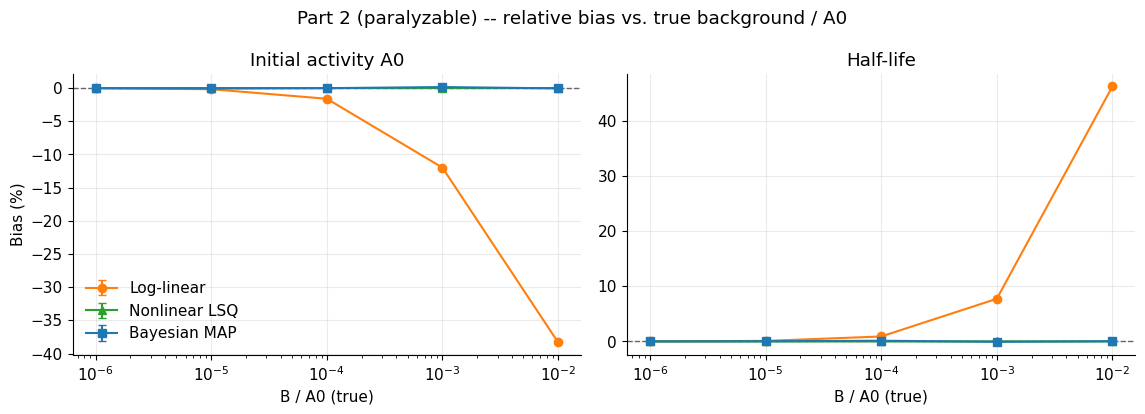

In [13]:
fig = plot_metric(
    part2_summary, "b_ratio",
    [("A0", "Initial activity A0"), ("t12", "Half-life")],
    "bias_pct", "Part 2 (paralyzable) -- relative bias vs. true background / A0", "B / A0 (true)", "Bias (%)",
    ref_line=0.0,
)
plt.show()


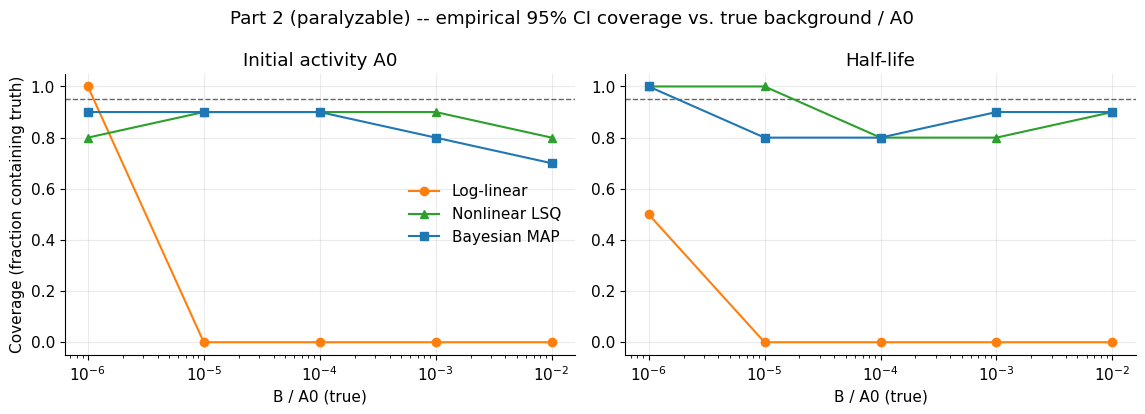

In [14]:
fig = plot_metric(
    part2_summary, "b_ratio",
    [("A0", "Initial activity A0"), ("t12", "Half-life")],
    "coverage", "Part 2 (paralyzable) -- empirical 95% CI coverage vs. true background / A0", "B / A0 (true)",
    "Coverage (fraction containing truth)", ref_line=0.95,
)
for ax in fig.axes:
    ax.set_ylim(-0.05, 1.05)
plt.show()


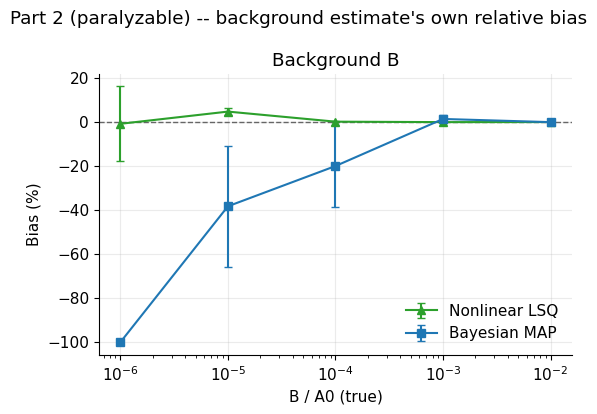

In [15]:
fig = plot_metric(
    part2_summary, "b_ratio", [("B", "Background B")],
    "bias_pct", "Part 2 (paralyzable) -- background estimate's own relative bias",
    "B / A0 (true)", "Bias (%)", ref_line=0.0,
)
plt.show()


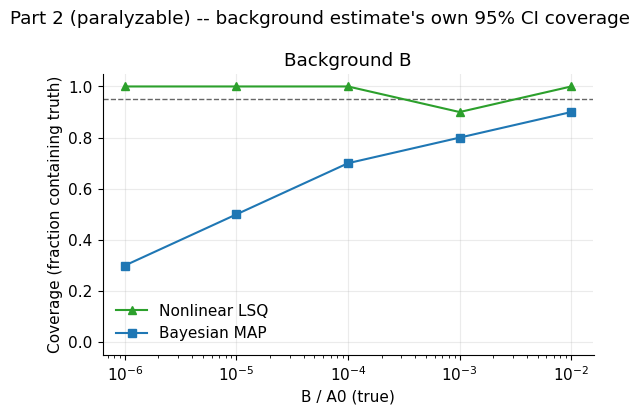

In [16]:
fig = plot_metric(
    part2_summary, "b_ratio", [("B", "Background B")],
    "coverage", "Part 2 (paralyzable) -- background estimate's own 95% CI coverage", "B / A0 (true)",
    "Coverage (fraction containing truth)", ref_line=0.95,
)
fig.axes[0].set_ylim(-0.05, 1.05)
plt.show()


In [17]:
print_bias_summary(part2_summary, "Part 2 (paralyzable)")


Part 2 (paralyzable) (bias, log-linear / nonlinear-LSQ / MAP):
  A0:
    b_ratio=0.01: Log-linear=-38.30%  Nonlinear LSQ= +0.00%  Bayesian MAP= -0.05%
    b_ratio=0.001: Log-linear=-11.99%  Nonlinear LSQ= -0.00%  Bayesian MAP= +0.15%
    b_ratio=0.0001: Log-linear= -1.61%  Nonlinear LSQ= +0.00%  Bayesian MAP= -0.01%
    b_ratio=1e-05: Log-linear= -0.17%  Nonlinear LSQ= +0.00%  Bayesian MAP= -0.06%
    b_ratio=1e-06: Log-linear= -0.02%  Nonlinear LSQ= +0.00%  Bayesian MAP= -0.02%
  half-life:
    b_ratio=0.01: Log-linear=+46.21%  Nonlinear LSQ= +0.00%  Bayesian MAP= +0.04%
    b_ratio=0.001: Log-linear= +7.73%  Nonlinear LSQ= +0.00%  Bayesian MAP= -0.07%
    b_ratio=0.0001: Log-linear= +0.89%  Nonlinear LSQ= +0.00%  Bayesian MAP= +0.12%
    b_ratio=1e-05: Log-linear= +0.09%  Nonlinear LSQ= -0.00%  Bayesian MAP= +0.03%
    b_ratio=1e-06: Log-linear= +0.01%  Nonlinear LSQ= -0.00%  Bayesian MAP= +0.01%
  background:
    b_ratio=0.01: Nonlinear LSQ= +0.00%  Bayesian MAP= -0.04%
    b_ratio=

**Reading Part 2**: the same pattern as Part 1. The dead-time model changes the
dead-time correction applied, not which estimator handles background well -- see
the Conclusions section below for the overall comparison across both parts.

(The B/A0=10<sup>-6</sup> timing above, ~61000s vs. the other points'
~250-450s, is a host-machine scheduling artifact from this particular run --
not a real cost of that setting -- the result itself is unaffected.)


## Conclusions

The numbers below are read directly off the tables/plots produced above (all
Monte Carlo settings -- `B_RATIOS`, `N_REP`, `FIT_CONFIG_NONPARA`/`FIT_CONFIG_PARA`
-- are plain variables in the code cells and can be edited to re-run with more
repetitions or different values; re-running will shift the exact figures quoted
here, though the pattern was consistent between the non-paralyzable and
paralyzable dead-time models).

**Log-linear fails exactly as its docstring predicts**: bias on A0 and half-life
grows sharply as B/A0 increases (-38%/+46% at B/A0=10<sup>-2</sup>, falling off
roughly in proportion to B/A0 at smaller ratios), with ~0% empirical coverage of
its own 95% CI throughout. Not a surprise -- it never estimates background at
all -- but it calibrates how much is actually gained by fixing just that one gap.

**Nonlinear LSQ vs. Bayesian MAP on A0/half-life -- the real question**: once the
classical fit also estimates background, its point-estimate bias on A0 and
half-life drops to ~0.00-0.004% at *every* background level tested, for both
dead-time models -- small enough to be consistent with pure Monte Carlo noise
(`bias_sem_pct` is usually of similar size). The Bayesian MAP estimator's bias is
also small (mostly under 0.3%) but is **not smaller** than the nonlinear fit's --
if anything the nonlinear fit's point estimates were *more* consistently close to
zero. For pure point-estimate accuracy of A0 and half-life in this scenario, the
full Bayesian treatment does not show a measurable edge over a classical fit that
simply stops ignoring background.

**Background B is where the two estimators genuinely diverge -- in opposite
directions**. The nonlinear fit's B estimate is unbiased but noisy (its relative
bias swings sign and grows large in *percentage* terms as the true B shrinks
toward zero -- expected, since a fixed absolute noise floor becomes a huge
relative error once the true value is tiny). The Bayesian MAP's B estimate, by
contrast, shows a **systematic, one-directional shrinkage toward zero** that
grows worse as B/A0 shrinks: roughly -4% (B/A0=10<sup>-3</sup>), -9% to -20%
(10<sup>-4</sup>), -38% (10<sup>-5</sup>, paralyzable), and effectively -100%
(10<sup>-6</sup> -- the MAP estimate collapses to ~0 regardless of the true
0.05 cps). This is the signature of the exponential prior's mode sitting exactly
at B=0 (see `Priors`' docstring) pulling the estimate down once the likelihood
alone is too weak, at that small a B, to fully overrule it with the prior scale
used here (`b_prior_scale = 0.1 * A0`).

That shrinkage shows up directly in **coverage**: the nonlinear fit's background
CI coverage stayed close to or above the nominal 95% across the entire sweep for
both dead-time models. The Bayesian MAP's background coverage degraded clearly
and monotonically as B/A0 shrank -- from ~0.8-0.9 at the larger ratios down to
0.3 at B/A0=10<sup>-6</sup> for both models -- a real, visible failure mode, not
Monte Carlo noise (`N_REP` draws at 0.3 vs. a nominal 0.95 is many standard
errors off). A0 and half-life's own coverage stayed broadly comparable between
the two estimators (both mostly in the 0.6-1.0 range, within what `N_REP` draws
can resolve).

**Bottom line**: in this scenario, upgrading the classical fit to include
background already recovers essentially all of the Bayesian MAP estimator's
point-estimate advantage over log-linear -- the "fuller model" didn't need to be
Bayesian to fix log-linear's main flaw. Where the Bayesian treatment measurably
*underperformed* here was specifically the background estimate once the true
background became small relative to the chosen prior's effective information --
a consequence of the prior construction used (a `b_prior_scale` that is
generously wide across the *whole* sweep, but still informative enough to shrink
the estimate once the likelihood alone is weak at the smallest true B values),
not an inherent property of Bayesian methods in general. A practitioner should
not assume a Bayesian model is automatically better just because it is fuller --
and if they do use one, the prior's influence at the edges of its design range
is worth checking explicitly, exactly as the coverage plots above do.

### Possible follow-ups
- Narrow `b_prior_scale` sweep-by-sweep (e.g. scaling it with the TRUE B instead
  of a single fixed value across the whole sweep) to see whether the MAP
  background coverage failure at small B/A0 is specifically an artifact of using
  one generously-wide-but-fixed prior scale across five orders of magnitude of
  true B, rather than of the Bayesian approach itself.
- Try `bayesdecay.Priors.informative()` with an externally-known half-life (e.g.
  this notebook's own DDEP value) for the Bayesian MAP estimator, to see whether
  that changes its A0/half-life point-estimate accuracy relative to the
  nonlinear fit.
- Extend to other short-lived DDEP-evaluated nuclides for comparison.
- Increase `N_REP` and/or `FIT_CONFIG_NONPARA`/`FIT_CONFIG_PARA`'s `n_vis`/
  `n_is_samples` back toward the library's defaults for a less noisy,
  higher-resolution study (at the cost of a much longer run time).
